# **Project: Cambodian Tourism Chatbot (RNN)**
---


### **1. Project Overview**

> In this project, you will build a Natural Language Processing (NLP) model using a **Simple Recurrent Neural Network (RNN)**. The goal is to create a chatbot that can answer common questions about tourism in Cambodia, covering destinations, food, and travel logistics
---


### **2. Environment Setup**

Import all necessary libraries for data manipulation, visualization, and deep learning.


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import pickle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout


### **3. Data Acquisition & Exploration**
#### **3.1 Load Dataset**
**Instructions**: Load the `cambodia_tourism_dataset_large.csv` file and display the first 10 rows.


In [15]:
# TODO: Load the CSV file
df = pd.read_csv("cambodia_tourism_dataset_large.csv")
# TODO: Display the head of the dataframe
df.head(10)

,question,answer
0,can you explain where is angkor wat specifically.,angkor wat is in siem reap cambodia
1,give me details on what is angkor wat for me.,it is a famous temple in cambodia
2,hey what to do in siem reap specifically.,you can visit temples and night market
3,do you know where is bayon temple immediately.,bayon temple is in the center of angkor thom
4,do you know what is ta prohm specifically.,it is the jungle temple with giant trees in si...
5,hi how much is angkor pass thank you.,a 1-day pass is 37 dollars and a 3-day pass is...
6,do you know where to watch sunset in siem reap...,phnom bakheng is the most popular spot for sunset
7,what is pub street?,it is the nightlife hub of siem reap with bars...
8,is tonle sap near siem reap specifically.,yes it is the largest freshwater lake near sie...
9,can you tell me best time to visit temples,early morning at sunrise is the best time


#### **3.2 Dataset Analysis**
**Instructions**: Perform basic EDA. Calculate the total number of samples and the maximum length of the questions and answers.


In [16]:
# TODO: Print total number of rows
print(f"Total Number of Sample : {len(df)}")
# TODO: Find the maximum length (word count) of the 'question' and 'answer' columns
df['question_len'] = df['question'].apply(lambda x: len(str(x).split()))
df['answer_len']   = df['answer'].apply(lambda x: len(str(x).split()))

print(f"Max question length (words): {df['question_len'].max()}")
print(f"Max answer length  (words): {df['answer_len'].max()}")
print(f"Avg question length (words): {df['question_len'].mean():.1f}")
print(f"Avg answer length  (words): {df['answer_len'].mean():.1f}")
df[['question_len','answer_len']].describe()

Total Number of Sample : 2000
Max question length (words): 14
Max answer length  (words): 13
Avg question length (words): 8.7
Avg answer length  (words): 8.7


,question_len,answer_len
count,2000.000000,2000.000000
mean,8.681000,8.695500
std,1.654874,1.851619
min,4.000000,5.000000
25%,8.000000,7.000000
50%,9.000000,9.000000
75%,10.000000,10.000000
max,14.000000,13.000000


### **4. Data Preprocessing**
#### **4.1 Tokenization**
Convert text into numerical format. Fit a tokenizer on both questions and answers to build a shared vocabulary.


In [17]:
# Correct column names from generated CSV
inputs = df["question"].astype(str).tolist()
responses = df["answer"].astype(str).tolist()

In [18]:
# Tokenization
## Initialize the Tokenizer
tokenizer = Tokenizer(filters='', oov_token='<OOV>')
tokenizer.fit_on_texts(inputs)
vocab_size = len(tokenizer.word_index) + 1

X_seq = tokenizer.texts_to_sequences(inputs)

print(f"Total words in vocabulary: {vocab_size}")
print("Word Index Sample:", dict(list(tokenizer.word_index.items())[:10]))
print(f"\nOriginal:  {inputs[0]}")
print(f"Numerical: {X_seq[0]}")

Total words in vocabulary: 231
Word Index Sample: {'<OOV>': 1, 'is': 2, 'what': 3, 'where': 4, 'me': 5, 'you': 6, 'to': 7, 'for': 8, 'i': 9, 'in': 10}

Original:  can you explain where is angkor wat specifically.
Numerical: [14, 6, 15, 4, 2, 34, 37, 22]


In [6]:
# 1. See how many unique words were found
print(f"Total words in vocabulary: {vocab_size}")

# 2. Look at the first 10 words in the dictionary
print("Word Index Sample:", dict(list(tokenizer.word_index.items())[:10]))

# 3. Verify the conversion
sample_text = inputs[0]
sample_seq = X_seq[0]
print(f"\nOriginal: {sample_text}")
print(f"Numerical: {sample_seq}")

Total words in vocabulary: 421
Word Index Sample: {'is': 1, 'the': 2, 'in': 3, 'it': 4, 'you': 5, 'what': 6, 'to': 7, 'a': 8, 'for': 9, 'where': 10}

Original: can you explain where is angkor wat specifically.
Numerical: [13, 5, 24, 10, 1, 19, 37, 38]


#### Explanation
Since neural networks like a `SimpleRNN` cannot "read" text, we must convert words into unique integers.

**1. `Tokenizer(filters='')`**
By default, a tokenizer removes punctuation (like `?`, `!`, and `.`). By setting `filters=''`, we tell the model to keep the text exactly as it is. This is important if you want the chatbot to recognize the difference between a statement and a question.

**2. `tokenizer.fit_on_texts(inputs + responses)`**
This is the "learning" phase for the tokenizer. It scans every word in your dataset and builds a dictionary (a **Word Index**). Every unique word is assigned a specific number. 
*   *Example:* "Angkor" becomes `1`, "Wat" becomes `2`, "Siem" becomes `3`, and so on.

**3. `vocab_size = len(tokenizer.word_index) + 1`**
This calculates the total number of unique words the model knows. We add `+1` because the computer reserves the number **`0`** for a special task called "Padding" (filling empty space in short sentences).

**4. `texts_to_sequences`**
This is the final transformation. It takes your actual sentences and replaces the words with the numbers from the dictionary.

---

**Before (Text):**
> `"where is angkor wat"`

**The Word Index (Dictionary):**
> `{'where': 1, 'is': 2, 'angkor': 3, 'wat': 4}`

**After (`X_seq`):**
> `[1, 2, 3, 4]`

---


#### **4.2 Sequencing and Padding**
**Instructions**: Convert the text strings into sequences of integers and pad them so they all have the same length. Explain why padding is necessary for RNNs.


In [7]:
# Padding
# Calculate max_len based on 95th percentile or max to keep sequences uniform
max_len = max(
    max(len(seq) for seq in X_seq), 
    max(len(seq) for seq in y_seq)
)
print(f"max len (padding target): {max_len}")

# TODO: Pad the sequences to ensure uniform length for model input
X = pad_sequences(X_seq, maxlen=max_len, padding='post')
y = pad_sequences(y_seq, maxlen=max_len, padding='post')

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

max len (padding target): 14
X shape: (2000, 14)
y shape: (2000, 14)


#### **4.3 Train-Test Split**
**Instructions**: Split the data into 80% training and 20% testing sets to evaluate your model's performance on unseen data.


In [20]:
# TODO: Split X and y using train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples  : {len(X_train)}")
print(f"Test samples      : {len(X_test)}")


Training samples  : 1600
Test samples      : 400


In [21]:
# 5. One-hot encoding for the targets
# Note: With large vocab_size, this uses a lot of RAM. 

# One-hot encode the class labels for categorical_crossentropy
y_train_oh = tf.keras.utils.to_categorical(y_train, num_classes=num_classes)
y_test_oh  = tf.keras.utils.to_categorical(y_test,  num_classes=num_classes)

print(f"\ny_train_oh shape: {y_train_oh.shape}  → (samples, num_classes=71)")
print("Integer format:", y_train[0], "→ one-hot:", y_train_oh[0][:5], "...")




y_train_oh shape: (1600, 71)  → (samples, num_classes=71)
Integer format: 22 → one-hot: [0. 0. 0. 0. 0.] ...


This step, known as **One-Hot Encoding**, is where we transform our target word IDs into a format that the model can use to calculate "how wrong" its guess was during training.

**1. What is One-Hot Encoding?**
In the previous step, we turned words into integers (e.g., "Angkor" = 3). However, we cannot simply use the number `3` as a final answer for the model to predict. If the model guesses `2` instead of `3`, the math would suggest it was "close." In language, word #2 and word #3 are completely different concepts, not "close" numbers.

**One-Hot Encoding** fixes this by turning each integer into a **binary vector**. Every position in the vector is `0`, except for the specific index of the word, which is `1`.

**Example:**
If our vocabulary is only 5 words: `[apple, banana, angkor, wat, siem]`
*   The word **"angkor"** (index 2) becomes: `[0, 0, 1, 0, 0]`
*   The word **"apple"** (index 0) becomes: `[1, 0, 0, 0, 0]`

**2. Why use `tf.keras.utils.to_categorical`?**
This function automates that transformation. It takes your list of integers (`y_train`) and creates a massive table (matrix) of `0`s and `1`s. This allows the final layer of your RNN (the **Softmax** layer) to output a probability for every single word in your dictionary.

### **5. Model Architecture Design**
#### **5.1 Design Strategy**
**Instructions**: Outline and define your model architecture. You are required to use an **Embedding Layer** and a **SimpleRNN**. 

In [23]:
# TODO: Define the Sequential model
# TODO: Add Embedding layer (with mask_zero=True)
# TODO: Add SimpleRNN layer
# TODO: Add Dense layer with Softmax activation

# Define the Sequential model
EMBEDDING_DIM = 64
RNN_UNITS     = 128

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=EMBEDDING_DIM,
              input_length=max_len, mask_zero=True),
    SimpleRNN(RNN_UNITS, activation='tanh', return_sequences=False),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(num_classes, activation='softmax')
], name="Cambodia_RNN_Classifier")

model.summary()

c:\Users\Hour\anaconda3\envs\fn_proj\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "Cambodia_RNN_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

#### **5.2 Compilation**
**Instructions**: Compile the model

In [24]:
# TODO: Compile the model

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print("Model compiled!")

Model compiled!


### **6. Training and Evaluation**
#### **6.1 Model Training**
**Instructions**: Train the model for at least 50-100 epochs. Use the test set as validation data.


In [25]:
# TODO: Run model.fit() and save the history


from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_accuracy', patience=15,
    restore_best_weights=True, verbose=1
)

history = model.fit(
    X_train, y_train_oh,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test_oh),
    callbacks=[early_stop],
    verbose=1
)

print(f"\nBest val accuracy: {max(history.history['val_accuracy']):.4f}")

Epoch 1/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - accuracy: 0.0800 - loss: 4.1915 - val_accuracy: 0.2350 - val_loss: 4.0073
Epoch 2/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.2450 - loss: 3.4482 - val_accuracy: 0.4225 - val_loss: 2.6209
Epoch 3/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.5888 - loss: 1.9102 - val_accuracy: 0.8100 - val_loss: 1.1719
Epoch 4/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.8537 - loss: 0.8693 - val_accuracy: 0.9375 - val_loss: 0.5332
Epoch 5/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.9519 - loss: 0.4117 - val_accuracy: 0.9725 - val_loss: 0.2792
Epoch 6/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.9762 - loss: 0.2316 - val_accuracy: 0.9875 - val_loss: 0.1458
Epoch 7/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.9900 - loss: 0.1380 - val_accuracy: 0.9950 - val_loss: 0.0939
Epoch 8/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.9919 - loss: 0.0892 - val_accuracy: 0.

In [26]:
# Save the trained model and tokenizer 
model.save("model_v2.h5")

with open("tokenizer_v2.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

with open("config_v2.pkl", "wb") as f:
    pickle.dump({
        "max_len"     : max_len,
        "num_classes" : num_classes,
        "id_to_answer": id_to_answer
    }, f)

print("Saved: model_v2.h5 | tokenizer_v2.pkl | config_vv2.pkl")

Saved: model_v2.h5 | tokenizer_v2.pkl | config_vv2.pkl


In [24]:
# NEW - use native Keras format 
### model.save("model.keras")

model.save("model.h5")


#### **6.2 Performance Visualization**
**Instructions**: Plot the training and validation loss over time. Identify if the model is overfitting.


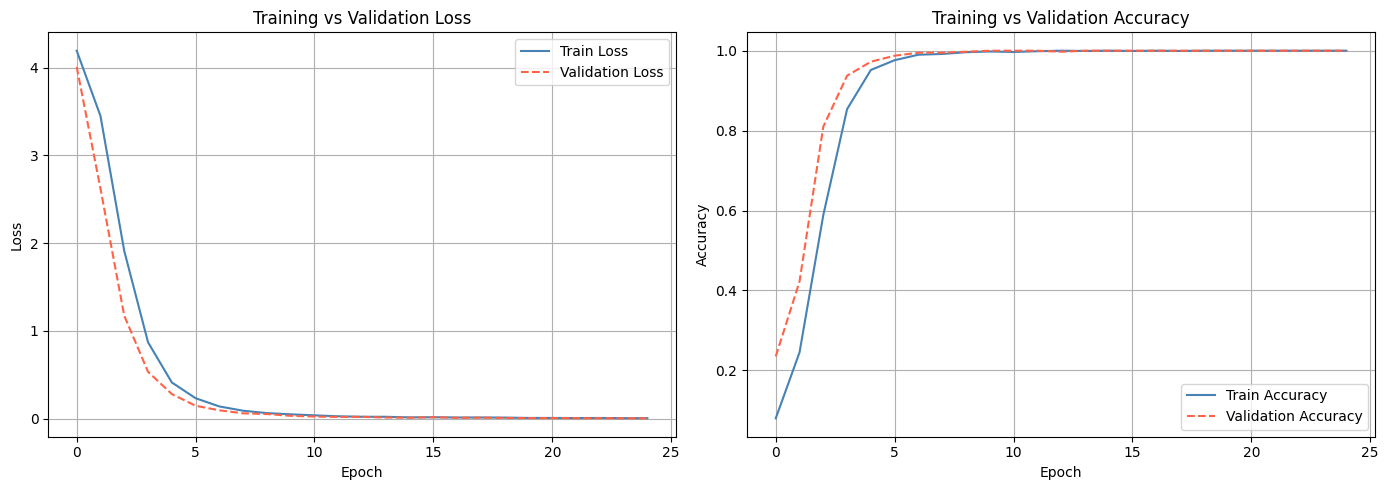


If val_loss rises while train_loss falls → the model is OVERFITTING.


In [27]:
# TODO: Create a line chart for loss and accuracy

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Loss ---
axes[0].plot(history.history['loss'],     label='Train Loss',      color='steelblue')
axes[0].plot(history.history['val_loss'], label='Validation Loss', color='tomato', linestyle='--')
axes[0].set_title('Training vs Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# --- Accuracy ---
axes[1].plot(history.history['accuracy'],     label='Train Accuracy',      color='steelblue')
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', color='tomato', linestyle='--')
axes[1].set_title('Training vs Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()
print("\nIf val_loss rises while train_loss falls → the model is OVERFITTING.")

### **7. Testing the Chatbot**
#### **7.1 Inference Test**
**Instructions**: Write a prediction. Able to do string input, processes it, and returns the model's predicted response.


In [20]:
# TODO: Write a code to do prediction answers for new questions
# TODO: Test with 3 different questions about Cambodia Tourism and print the predicted answers

def generate_response(text):
    """Convert input text to a sequence, run the model, decode the output."""
    seq = tokenizer.texts_to_sequences([text])
    seq = pad_sequences(seq, maxlen=max_len, padding='post')

    pred = model.predict(seq, verbose=0)          # shape: (1, max_len, vocab_size)
    pred = np.argmax(pred, axis=-1)[0]            # shape: (max_len,)  — integer IDs

    # Build reverse lookup: index → word
    index_to_word = {v: k for k, v in tokenizer.word_index.items()}

    result = []
    for idx in pred:
        if idx != 0:                              # 0 is the padding token — skip it
            word = index_to_word.get(idx, "")
            if word:
                result.append(word)

    return " ".join(result)


# ── Test with 5 Cambodia tourism questions ──────────────────────────────────
test_questions = [
    "where is angkor wat",
    "what food should i try in cambodia",
    "best time to visit cambodia",
    "is cambodia safe",
    "how to travel in phnom penh"
]

print("=" * 60)
for q in test_questions:
    answer = generate_response(q)
    print(f"Q: {q}")
    print(f"A: {answer}")
    print("-" * 60)

Q: where is angkor wat
A: it is is in in in in in in in in in in in
------------------------------------------------------------
Q: what food should i try in cambodia
A: it should try amok and lok
------------------------------------------------------------
Q: best time to visit cambodia
A: early morning at sunrise the the the the the the the the the the
------------------------------------------------------------
Q: is cambodia safe
A: yes is generally generally generally generally generally generally generally generally generally generally generally generally
------------------------------------------------------------
Q: how to travel in phnom penh
A: passapp or use tuk tuk tuks tuks tuks tuks tuks tuks tuks tuks tuks
------------------------------------------------------------


In [22]:
# Error analysis: questions the model is likely to fail on
error_cases = [
    ("What's the weather like?",        "Out-of-domain question"),
    ("Angkor Wat location?",             "Different phrasing / short form"),
    ("WHERE IS ANGKOR WAT",              "Uppercase input"),
    ("What is the population of Siem Reap?", "Specific fact not in dataset"),
    ("Can you book a hotel for me?",     "Task the chatbot cannot perform"),
]

print("=" * 70)
print(f"{'Input':<40} {'Failure Type':<30}")
print("=" * 70)
for q, reason in error_cases:
    answer = generate_response(q)
    print(f"Q : {q}")
    print(f"A : {answer}")
    print(f"Expected failure reason: {reason}")
    print("-" * 70)

Input                                    Failure Type                  
Q : What's the weather like?
A : to to to to to to to to to to to to to to
Expected failure reason: Out-of-domain question
----------------------------------------------------------------------
Q : Angkor Wat location?
A : siem it it it it it it it it it it it it it
Expected failure reason: Different phrasing / short form
----------------------------------------------------------------------
Q : WHERE IS ANGKOR WAT
A : it is is in in in in in in in in in in in
Expected failure reason: Uppercase input
----------------------------------------------------------------------
Q : What is the population of Siem Reap?
A : it is gmt famous the city city city city city city city city city
Expected failure reason: Specific fact not in dataset
----------------------------------------------------------------------
Q : Can you book a hotel for me?
A : it is usually safe safe safe safe safe safe safe safe safe safe safe
Expected 

### **8. Conclusion & Reflection**
**Instructions**: Summarize your findings. What were the challenges with the SimpleRNN? How would you improve this chatbot?


#### Write your reflection here
- 1. **Rephrased questions:** The model memorises surface patterns, not meaning. "Where is Angkor Wat?" and "Angkor Wat location?" share almost no words in common, so the model treats them as completely different inputs even though they mean the same thing.
- 2. **Out-of-domain questions:** Questions about topics absent from the dataset (weather, booking, population figures) produce random-looking outputs because the model has never been trained on those patterns.
-
-
##### To Improve 
- Replace SimpleRNN with **LSTM or GRU** to capture longer dependencies.
- Add **lowercasing and punctuation removal** in preprocessing to reduce sensitivity.